In [261]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [262]:
REGION = 'ExtNord'
YEAR = 2024

In [263]:
grouped_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', encoding=enc)
grouped_file_previous = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR-1}_grouped.csv', encoding=enc)

In [264]:
grouped_file.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,27.12,36.12,18.12,14.87,39.70,0.0,0.0,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,27.63,36.88,18.38,15.08,41.01,0.0,0.0,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,27.10,35.55,18.65,15.74,39.24,0.0,0.0,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,26.63,34.88,18.37,14.86,38.66,0.0,0.0,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,27.47,36.49,18.46,15.50,40.42,0.0,0.0,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648


In [265]:
grouped_file.shape

(3804, 74)

In [266]:
grouped_file_previous.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023-01,2023,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.187878,-0.156346,-0.300192,0.156346,0.197311,-0.148100,-0.299928,0.148100,0.020541,0.020739,0.020337,0.020739,26.53,34.76,18.30,15.35,42.63,0.0004,0.0120,0.0120,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,30.88,21.42,57.88,354.92,51.0,14.0,37.0,29.17,28.33,36.00,28.00,1400.0,457.0,0.0,121.31,944.0,0.0,150.0,890.0
1,2023-01,2023,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.197260,-0.163545,-0.285764,0.163545,0.194516,-0.160066,-0.284314,0.160066,0.017295,0.015286,0.012863,0.015286,27.24,36.00,18.49,15.78,43.18,0.0000,0.0000,0.0000,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,31.38,21.75,58.78,366.88,52.0,15.0,37.0,29.17,29.33,36.33,27.67,1373.0,452.0,0.0,123.78,943.0,0.0,131.0,890.0
2,2023-01,2023,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.190635,-0.145933,-0.299990,0.145933,0.189253,-0.141761,-0.304995,0.141761,0.014423,0.013858,0.012037,0.013858,26.43,33.91,18.95,16.07,42.30,0.0000,0.0000,0.0000,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,30.67,21.00,60.00,289.46,50.0,15.0,35.0,29.00,28.67,34.83,28.33,1415.0,464.0,0.0,121.63,939.0,0.0,134.0,924.0
3,2023-01,2023,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.199468,-0.152547,-0.295942,0.152547,0.195681,-0.154843,-0.297084,0.154843,0.012125,0.013449,0.013391,0.013449,26.37,33.78,18.95,16.49,42.00,0.0001,0.0017,0.0017,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,30.42,21.00,61.76,318.97,49.0,15.0,34.0,29.17,28.00,35.00,28.00,1475.0,464.0,0.0,117.63,962.0,0.0,162.0,949.0
4,2023-01,2023,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.188067,-0.148213,-0.310075,0.148213,0.187600,-0.148272,-0.299822,0.148272,0.021219,0.020131,0.018398,0.020131,27.28,35.70,18.86,15.92,42.76,0.0000,0.0000,0.0000,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,30.79,22.08,59.68,324.36,51.0,14.0,37.0,29.17,28.50,35.33,28.00,1449.0,475.0,0.0,121.57,964.0,0.0,135.0,947.0


In [267]:
grouped_file_previous.shape

(3804, 74)

In [268]:
grouped_file['dt_placement'] = pd.to_datetime(grouped_file['dt_placement'], errors='coerce').dt.to_period('M')
grouped_file_previous['dt_placement'] = pd.to_datetime(grouped_file_previous['dt_placement'], errors='coerce').dt.to_period('M')

In [269]:
grouped_file

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,27.12,36.12,18.12,14.87,39.70,0.0000,0.0000,0.0000,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
1,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,27.63,36.88,18.38,15.08,41.01,0.0000,0.0000,0.0000,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
2,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,27.10,35.55,18.65,15.74,39.24,0.0000,0.0000,0.0000,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
3,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,26.63,34.88,18.37,14.86,38.66,0.0000,0.0000,0.0000,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
4,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,27.47,36.49,18.46,15.50,40.42,0.0000,0.0000,0.0000,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648,-2147483648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [270]:
biovars_temp = grouped_file_previous[['year', 'GID0', 'GID1', 'GID2', 'GID3'] + [col for col in grouped_file_previous.columns if 'bio' in col] ].copy()
biovars_temp.rename(columns={'year': 'year_biovars'}, inplace=True)

In [271]:
biovars_df = (
    biovars_temp
    .groupby(['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'])
    .mean(numeric_only=True)
    .reset_index()
    .round(2)
)

In [272]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023,extreme nord,diamare,bogo,balaza,30.88,21.42,57.88,354.92,51.0,14.0,37.0,29.17,28.33,36.00,28.00,1400.0,457.0,0.0,121.31,944.0,0.0,150.0,890.0
1,2023,extreme nord,diamare,bogo,balda,31.38,21.75,58.78,366.88,52.0,15.0,37.0,29.17,29.33,36.33,27.67,1373.0,452.0,0.0,123.78,943.0,0.0,131.0,890.0
2,2023,extreme nord,diamare,bogo,bogo,30.67,21.00,60.00,289.46,50.0,15.0,35.0,29.00,28.67,34.83,28.33,1415.0,464.0,0.0,121.63,939.0,0.0,134.0,924.0
3,2023,extreme nord,diamare,bogo,borai,30.42,21.00,61.76,318.97,49.0,15.0,34.0,29.17,28.00,35.00,28.00,1475.0,464.0,0.0,117.63,962.0,0.0,162.0,949.0
4,2023,extreme nord,diamare,bogo,guinggley,30.79,22.08,59.68,324.36,51.0,14.0,37.0,29.17,28.50,35.33,28.00,1449.0,475.0,0.0,121.57,964.0,0.0,135.0,947.0


In [273]:
biovars_df.shape

(317, 24)

In [274]:
df_current = grouped_file.drop(columns=[col for col in grouped_file.columns if 'bio' in col]).copy()

In [275]:
df_current.shape

(3804, 55)

In [276]:
df_current['year_biovars'] = df_current['year']-1

In [277]:
df_current.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars
0,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,27.12,36.12,18.12,14.87,39.70,0.0,0.0,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,2023
1,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,27.63,36.88,18.38,15.08,41.01,0.0,0.0,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,2023
2,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,27.10,35.55,18.65,15.74,39.24,0.0,0.0,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,2023
3,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,26.63,34.88,18.37,14.86,38.66,0.0,0.0,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,2023
4,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,27.47,36.49,18.46,15.50,40.42,0.0,0.0,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,2023


In [278]:
df_current.shape

(3804, 56)

In [279]:
biovars_df.head()

,year_biovars,GID0,GID1,GID2,GID3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2023,extreme nord,diamare,bogo,balaza,30.88,21.42,57.88,354.92,51.0,14.0,37.0,29.17,28.33,36.00,28.00,1400.0,457.0,0.0,121.31,944.0,0.0,150.0,890.0
1,2023,extreme nord,diamare,bogo,balda,31.38,21.75,58.78,366.88,52.0,15.0,37.0,29.17,29.33,36.33,27.67,1373.0,452.0,0.0,123.78,943.0,0.0,131.0,890.0
2,2023,extreme nord,diamare,bogo,bogo,30.67,21.00,60.00,289.46,50.0,15.0,35.0,29.00,28.67,34.83,28.33,1415.0,464.0,0.0,121.63,939.0,0.0,134.0,924.0
3,2023,extreme nord,diamare,bogo,borai,30.42,21.00,61.76,318.97,49.0,15.0,34.0,29.17,28.00,35.00,28.00,1475.0,464.0,0.0,117.63,962.0,0.0,162.0,949.0
4,2023,extreme nord,diamare,bogo,guinggley,30.79,22.08,59.68,324.36,51.0,14.0,37.0,29.17,28.50,35.33,28.00,1449.0,475.0,0.0,121.57,964.0,0.0,135.0,947.0


In [280]:
biovars_df.shape

(317, 24)

In [281]:
dataset = pd.merge(
    df_current, 
    biovars_df, 
    on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], 
    how='left'
)

In [282]:
dataset = pd.merge(df_current, biovars_df, on=['year_biovars', 'GID0', 'GID1', 'GID2', 'GID3'], how='inner')

In [283]:
dataset.shape

(3804, 75)

<Axes: >

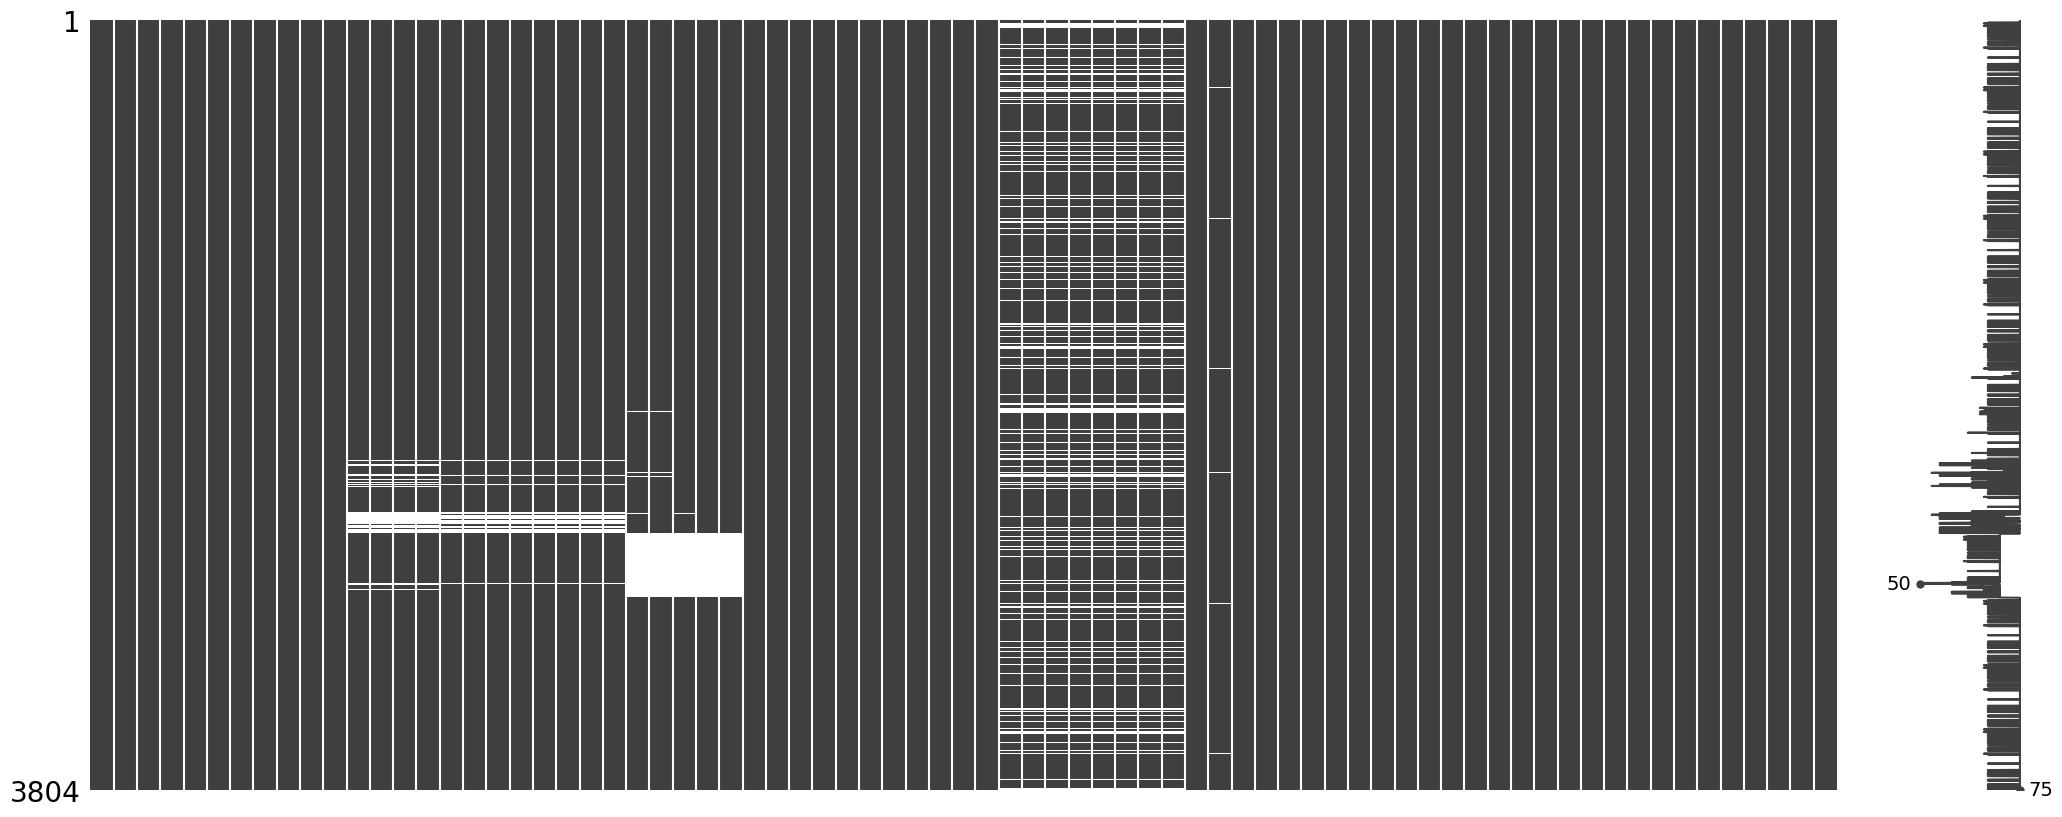

In [284]:
msno.matrix(dataset)

In [285]:
dataset

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.208538,-0.143898,-0.330832,0.143898,0.218956,-0.140636,-0.331677,0.140636,0.022833,0.021348,0.019012,0.021348,27.12,36.12,18.12,14.87,39.70,0.0000,0.0000,0.0000,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,2023,30.88,21.42,57.88,354.92,51.0,14.0,37.0,29.17,28.33,36.00,28.00,1400.0,457.0,0.0,121.31,944.0,0.0,150.0,890.0
1,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.208756,-0.160724,-0.308649,0.160724,0.208451,-0.159138,-0.309112,0.159138,0.020272,0.015680,0.014424,0.015680,27.63,36.88,18.38,15.08,41.01,0.0000,0.0000,0.0000,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,2023,31.38,21.75,58.78,366.88,52.0,15.0,37.0,29.17,29.33,36.33,27.67,1373.0,452.0,0.0,123.78,943.0,0.0,131.0,890.0
2,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.211932,-0.138166,-0.326704,0.138166,0.211937,-0.130861,-0.333376,0.130861,0.017759,0.014456,0.012339,0.014456,27.10,35.55,18.65,15.74,39.24,0.0000,0.0000,0.0000,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,2023,30.67,21.00,60.00,289.46,50.0,15.0,35.0,29.00,28.67,34.83,28.33,1415.0,464.0,0.0,121.63,939.0,0.0,134.0,924.0
3,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.221416,-0.132245,-0.326718,0.132245,0.220404,-0.136357,-0.328987,0.136357,0.015525,0.013749,0.013668,0.013749,26.63,34.88,18.37,14.86,38.66,0.0000,0.0000,0.0000,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,2023,30.42,21.00,61.76,318.97,49.0,15.0,34.0,29.17,28.00,35.00,28.00,1475.0,464.0,0.0,117.63,962.0,0.0,162.0,949.0
4,2024-01,2024,1,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.197396,-0.143470,-0.329282,0.143470,0.199466,-0.145577,-0.324719,0.145577,0.024345,0.021058,0.019762,0.021058,27.47,36.49,18.46,15.50,40.42,0.0000,0.0000,0.0000,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,2023,30.79,22.08,59.68,324.36,51.0,14.0,37.0,29.17,28.50,35.33,28.00,1449.0,475.0,0.0,121.57,964.0,0.0,135.0,947.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,2024-12,2024,12,0.0,1.000,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,0.225063,-0.138509,-0.333837,0.138509,0.231870,-0.128666,-0.337224,0.128666,0.008417,0.007810,0.008633,0.007810,24.04,29.99,18.09,15.84,34.86,0.0461,1.4300,1.4300,108691.34,1322.49,4.33,172.99,759.46,179.21,0.0,62.92,2224.04,1215.46,3.21,70.29,46.80,2.81,0.0,93.52,31,36.0,30,12,12,3,5,8,2023,28.62,21.75,60.42,303.86,48.0,12.0,36.0,28.17,27.00,32.83,25.67,1483.0,456.0,0.0,126.10,1066.0,1.0,168.0,696.0
3800,2024-12,2024,12,0.0,1.000,extreme nord,mayo-tsanaga

In [286]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc)